---
## 1. Imports and Configuration

- **spaCy** handles tokenization, POS tagging, and dependency parsing
- **pandas** manages the structured extraction output
- **pathlib** provides clean cross-platform file handling
- **re** enables word-boundary-aware text matching

In [2]:
import os
import re
from pathlib import Path
import pandas as pd
import spacy

import matplotlib.pyplot as plt
import seaborn as sns

# ── File paths ────────────────────────────────────────────────
CORPUS_DIR = Path("corpus")      # expects corpus/fox/ and corpus/nyt/
OUTPUT_CSV = "extractions.csv"
EUPH_CSV   = "euphemisms.csv"

print("loaded successfully")
print(f"Corpus directory: {CORPUS_DIR.resolve()}")

Imports loaded successfully.
Corpus directory: /Users/aaryanshanbhag/repos/linguistic-bias-analysis/corpus


---
## 2. Target Verb Lexicon

We define the set of **target verbs** whose argument structure we want to analyse. These are grouped into three semantic classes:

| Class | Purpose | Examples |
|---|---|---|
| **Material / violent** | Direct physical actions | shoot, kill, kneel, pin, restrain |
| **Custodial** | Police procedure | arrest, detain, handcuff, subdue |
| **Verbal / cognitive** | Source attribution | say, claim, allege, deny |

Verbal-process verbs are included because they capture *epistemic framing* — whose claims get attributed vs. asserted directly.

In [3]:
TARGET_VERBS = {
    # Material / violent
    "shoot", "kill", "die", "kneel", "press", "pin", "restrain",
    "arrest", "detain", "subdue", "hold", "handcuff", "choke",
    "strike", "hit", "beat", "tase", "fire", "gasp", "breathe",
    "punch", "kick", "throw", "drag", "force", "push", "shove",
    "stop", "approach", "confront", "encounter", "chase", "pursue",
    # Death / medical
    "pronounce", "asphyxiate", "suffocate", "lose", "plead",
    # Verbal / cognitive (source attribution)
    "say", "claim", "allege", "tell", "report", "state",
    "deny", "confirm", "acknowledge", "ask", "respond",
    "warn", "order", "command",
}

print(f"Target verb lexicon: {len(TARGET_VERBS)} verbs across 3 semantic classes")

Target verb lexicon: 52 verbs across 3 semantic classes


---
## 3. Hedging Markers and Actor Classification Rules

### 3a. Hedging lexicon

**Epistemic hedging** (Hyland, 2005) refers to linguistic markers that signal the speaker's uncertainty or distance from a claim. In news discourse, hedges like *allegedly* and *reportedly* are ideologically significant: they indicate *whose actions* an outlet treats as settled vs. provisional.

### 3b. Actor classification rules

Each extracted agent/patient noun phrase is classified into one of five categories using **head-noun lemma matching**. Rules are ordered by specificity — named individuals (Chauvin, Floyd) are matched before generic role nouns (officer, man).

In [4]:
# ── Epistemic hedging markers ─────────────────────────────────
HEDGES = {
    "allegedly", "reportedly", "apparently", "purportedly",
    "may", "might", "could", "seems", "seemed",
    "appears", "appeared", "claimed", "alleged", "reported"
}

# ── Actor classification rules (order = priority) ─────────────
ACTOR_RULES = [
    # Police: named officers + institutional referring expressions
    ("police", {
        "officer", "officers", "police", "cop", "cops", "deputy",
        "sheriff", "patrolman", "patrol", "chief", "lieutenant",
        "sergeant", "authorities", "authority", "investigator",
        "investigators", "official", "officials", "department",
        "force", "chauvin", "thao", "lane", "kueng", "derek", "tou",
    }),
    # Victim: named individuals + role nouns
    ("victim", {
        "floyd", "castile", "rice", "tamir", "philando", "george",
    }),
    # Civilian: bystanders, family, community members
    ("civilian", {
        "man", "woman", "boy", "girl", "child", "teen", "teenager",
        "bystander", "witness", "witnesses", "resident", "residents",
        "person", "people", "crowd", "protester", "protesters",
        "friend", "family", "brother", "mother", "father",
    }),
    # Suspect: criminal-role framing
    ("suspect", {
        "suspect", "suspects", "perpetrator", "criminal",
    }),
]

print(f"Hedging lexicon: {len(HEDGES)} markers")
print(f"Actor categories: {[r[0] for r in ACTOR_RULES]} + Other")

Hedging lexicon: 14 markers
Actor categories: ['police', 'victim', 'civilian', 'suspect'] + Other


---
## 4. Euphemism Lexicon

**Lexical framing** operates through the selection of near-synonymous expressions with different evaluative weights. We distinguish:

- **Euphemisms**: institutional/procedural phrasings that nominalize or obscure agency (e.g. *officer-involved shooting*, *in police custody*, *subdued*)
- **Direct phrasings**: agentive constructions that name the actor and action explicitly (e.g. *police shot*, *officer killed*, *knelt on*)

Counts are taken across each outlet's full corpus text using Python's `str.count()` substring search.

In [5]:
EUPHEMISM_PAIRS = {
    # Euphemisms — agency-obscuring institutional phrasings
    "officer-involved shooting": "euphemism",
    "officer involved shooting":  "euphemism",
    "officer-involved":           "euphemism",
    "in police custody":          "euphemism",
    "police custody":             "euphemism",
    "during the encounter":       "euphemism",
    "during the incident":        "euphemism",
    "altercation":                "euphemism",
    "use of force":               "euphemism",
    "fatal encounter":            "euphemism",
    "subdued":                    "euphemism",
    "neutralized":                "euphemism",
    "lost consciousness":         "euphemism",
    "went limp":                  "euphemism",
    # Direct phrasings — agentive constructions
    "police shot":                "direct",
    "officer shot":               "direct",
    "officer killed":             "direct",
    "officer kneeled":            "direct",
    "knelt on":                   "direct",
    "pinned":                     "direct",
}

euphemism_count = sum(1 for v in EUPHEMISM_PAIRS.values() if v == "euphemism")
direct_count    = sum(1 for v in EUPHEMISM_PAIRS.values() if v == "direct")
print(f"Euphemism lexicon: {euphemism_count} euphemisms, {direct_count} direct phrasings")

Euphemism lexicon: 14 euphemisms, 6 direct phrasings


---
## 5. Helper Functions

Four helper functions implement the core linguistic analysis:

| Function | Purpose | CDA device |
|---|---|---|
| `classify_actor()` | Map noun phrase → actor category | Transitivity |
| `get_subject()` | Extract grammatical subject + detect voice | Voice |
| `get_object()` | Extract direct object or oblique by-phrase agent | Transitivity |
| `has_hedge()` | Detect hedging markers in sentence | Epistemic hedging |

> **Note on voice detection:** passive constructions are identified by the presence of `nsubjpass` (passive subject) or `auxpass` (passive auxiliary) dependency labels. In passive constructions with a by-phrase agent (`agent → pobj`), the prepositional object is promoted to semantic agent. Agent-deleted passives (no by-phrase) are recorded as `agent_category = 'none'`.

In [6]:
def classify_actor(span_text):
    """Map noun-phrase string to actor category via head-noun matching."""
    if span_text is None:
        return "none"
    words = set(re.findall(r"\b\w+\b", span_text.lower()))
    for category, vocab in ACTOR_RULES:
        if words & vocab:           # set intersection: any match → this category
            return category
    return "other"


def get_subject(verb_token):
    """Return (subject_token, voice) for verb token.
    
      - nsubjpass dependency → passive subject   → voice = 'passive'
      - auxpass dependency   → passive auxiliary → voice = 'passive'
      - nsubj dependency     → active subject    → voice = 'active'
    """
    voice = "active"
    subj  = None
    for child in verb_token.children:
        if child.dep_ == "nsubj":
            subj  = child
            voice = "active"
        elif child.dep_ == "nsubjpass":
            subj  = child
            voice = "passive"
        elif child.dep_ == "auxpass":
            voice = "passive"
    return subj, voice


def get_object(verb_token):
    """Return (object_token, type) for a verb token.
    
    Returns:
      - (token, 'dobj')     for direct objects
      - (token, 'by_agent') for oblique by-phrase agents in passives
      - (None,  None)       if no object found
    """
    for child in verb_token.children:
        if child.dep_ in ("dobj", "obj"):
            return child, "dobj"
        if child.dep_ == "agent":           # 'by' preposition head
            for grand in child.children:
                if grand.dep_ == "pobj":    # the noun after 'by'
                    return grand, "by_agent"
    return None, None


def expand_span(token):
    """Return full noun-phrase text for token using its dependency subtree."""
    if token is None:
        return None
    return " ".join(t.text for t in token.subtree if t.dep_ != "punct")


def has_hedge(sent):
    """Return True if sentence contains any hedging marker (set intersection)."""
    sent_words = set(re.findall(r"\b\w+\b", sent.text.lower()))
    return bool(sent_words & HEDGES)


def strip_header(text):
    """Remove HEADLINE/OUTLET/DATE/URL/BYLINE metadata block from article files."""
    lines = text.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "" and i > 0:
            if any(l.startswith(("HEADLINE:", "OUTLET:", "DATE:", "URL:", "BYLINE:"))
                   for l in lines[:i]):
                return "\n".join(lines[i + 1:])
    return text


print("Helper functions defined: classify_actor, get_subject, get_object,")
print("                          expand_span, has_hedge, strip_header")

Helper functions defined: classify_actor, get_subject, get_object,
                          expand_span, has_hedge, strip_header


---
## 6. Load spaCy Model

We load spaCy's `en_core_web_sm` model, which provides:
- Tokenization and sentence boundary detection
- Part-of-speech (POS) tagging
- Dependency parsing (the core of our analysis)

If the model is not installed, run: `python -m spacy download en_core_web_sm`

In [7]:
print("Loading spaCy model...")
nlp = spacy.load("en_core_web_sm")
print(f"Model loaded: {nlp.meta['name']} v{nlp.meta['version']}")
print(f"Pipeline components: {nlp.pipe_names}")

Loading spaCy model...
Model loaded: core_web_sm v3.8.0
Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


---
## 7. Main Extraction Loop

For each article in the corpus, the pipeline:

1. Reads and strips the metadata header
2. Runs spaCy's full NLP pipeline on the article body
3. Iterates over sentences → tokens
4. For each token that is a **VERB** and whose lemma is in `TARGET_VERBS`:
   - Extracts grammatical subject and object
   - Determines voice (active/passive)
   - In passives with by-phrase: promotes by-phrase to semantic agent
   - Classifies agent and patient into actor categories
   - Flags sentence-level hedging
5. Appends a structured row to the output list

The output schema is: `article_id · outlet · sentence · verb_lemma · voice · agent_text · agent_category · patient_text · patient_category · hedged`

In [8]:
rows = []

for outlet_dir in sorted(CORPUS_DIR.iterdir()):
    if not outlet_dir.is_dir():
        continue
    outlet = outlet_dir.name

    for txt_file in sorted(outlet_dir.glob("*.txt")):
        article_id = f"{outlet}_{txt_file.stem}"
        print(f"  Processing: {article_id}")

        text = txt_file.read_text(encoding="utf-8")
        body = strip_header(text)
        doc  = nlp(body)

        for sent in doc.sents:
            for token in sent:

                # Filter: only VERB tokens in our target set
                if token.pos_ != "VERB":
                    continue
                if token.lemma_.lower() not in TARGET_VERBS:
                    continue

                # Extract argument structure
                subj, voice   = get_subject(token)
                obj, obj_type = get_object(token)

                # Promote by-phrase to semantic agent in passives
                if voice == "passive" and obj_type == "by_agent":
                    semantic_agent   = obj
                    semantic_patient = subj
                else:
                    semantic_agent   = subj
                    semantic_patient = obj

                agent_text   = expand_span(semantic_agent)
                patient_text = expand_span(semantic_patient)

                rows.append({
                    "article_id":       article_id,
                    "outlet":           outlet,
                    "sentence":         sent.text.strip().replace("\n", " "),
                    "verb_lemma":       token.lemma_.lower(),
                    "voice":            voice,
                    "agent_text":       agent_text,
                    "agent_category":   classify_actor(agent_text),
                    "patient_text":     patient_text,
                    "patient_category": classify_actor(patient_text),
                    "hedged":           has_hedge(sent),
                })

print(f"\nExtraction complete: {len(rows)} verb-instances")

  Processing: fox_floyd_01_two-cops-conduct-complaints
  Processing: fox_floyd_02_gentle-giant-profile
  Processing: fox_floyd_03_autopsy-results
  Processing: nyt_floyd_01_chauvin-floyd-worked-together
  Processing: nyt_floyd_02_knee-neck-floyd-death
  Processing: nyt_floyd_03_floyd-investigation
  Processing: nyt_floyd_04_autopsy-baden
  Processing: nyt_floyd_05_witness-morries-hall

Extraction complete: 264 verb-instances


---
## 8. Save Extractions and Print Summary Statistics

We save the raw extractions to CSV and print four summary tables:

- Distribution by outlet
- Top verbs by frequency
- Voice distribution (active vs. passive) by outlet
- Agent category distribution by outlet

In [9]:
df = pd.DataFrame(rows)
df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_CSV}")
print(f"Columns: {list(df.columns)}\n")

print("── Distribution by outlet ──────────────────────────────")
print(df["outlet"].value_counts())

print("\n── Top 15 verbs ────────────────────────────────────────")
print(df["verb_lemma"].value_counts().head(15))

print("\n── Voice distribution by outlet ────────────────────────")
print(df.groupby(["outlet", "voice"]).size().unstack(fill_value=0))

print("\n── Agent categories by outlet ──────────────────────────")
print(df.groupby(["outlet", "agent_category"]).size().unstack(fill_value=0))

print("\n── Patient categories by outlet ────────────────────────")
print(df.groupby(["outlet", "patient_category"]).size().unstack(fill_value=0))

Saved 264 rows to extractions.csv
Columns: ['article_id', 'outlet', 'sentence', 'verb_lemma', 'voice', 'agent_text', 'agent_category', 'patient_text', 'patient_category', 'hedged']

── Distribution by outlet ──────────────────────────────
outlet
nyt    195
fox     69
Name: count, dtype: int64

── Top 15 verbs ────────────────────────────────────────
verb_lemma
say        102
die         17
kill        12
hold        11
stop        10
report      10
breathe     10
arrest       9
fire         8
tell         8
respond      6
press        6
kneel        5
pin          4
plead        4
Name: count, dtype: int64

── Voice distribution by outlet ────────────────────────
voice   active  passive
outlet                 
fox         57       12
nyt        179       16

── Agent categories by outlet ──────────────────────────
agent_category  civilian  none  other  police  suspect  victim
outlet                                                        
fox                    2    12     33      15   

---
## 9. Euphemism Lexicon Analysis

Beyond clause-level analysis, we examine **lexical framing** at phrasal level. Each outlet's full corpus is concatenated into one text string and searched for each phrase in `EUPHEMISM_PAIRS` using `str.count()`. Results are saved to `euphemisms.csv`.

This operationalizes Bolinger's (1980) claim that lexical selection is ideological work: choice between *fatal encounter* and *police killed* is a framing decision, not merely a stylistic one.

In [10]:
euph_rows = []

for outlet_dir in sorted(CORPUS_DIR.iterdir()):
    if not outlet_dir.is_dir():
        continue
    outlet = outlet_dir.name

    # Concatenate all articles for this outlet into one searchable string
    full_text = " ".join(
        strip_header(f.read_text(encoding="utf-8"))
        for f in outlet_dir.glob("*.txt")
    ).lower()

    for phrase, ptype in EUPHEMISM_PAIRS.items():
        count = full_text.count(phrase)
        if count > 0:
            euph_rows.append({
                "outlet": outlet,
                "phrase": phrase,
                "type":   ptype,
                "count":  count,
            })

euph_df = pd.DataFrame(euph_rows)

if not euph_df.empty:
    euph_df.to_csv(EUPH_CSV, index=False)
    print("── Phrase counts by outlet ─────────────────────────────")
    print(euph_df.pivot_table(
        index="phrase", columns="outlet", values="count", fill_value=0
    ))
    print("\n── Direct vs. Euphemism totals by outlet ───────────────")
    print(euph_df.groupby(["outlet", "type"])["count"].sum().unstack(fill_value=0))
else:
    print("No euphemism phrases matched in corpus.")

── Phrase counts by outlet ─────────────────────────────
outlet              fox  nyt
phrase                      
altercation         0.0  1.0
fatal encounter     0.0  5.0
in police custody   0.0  3.0
knelt on            0.0  1.0
lost consciousness  0.0  1.0
officer shot        1.0  0.0
pinned              1.0  1.0
police custody      0.0  3.0
subdued             0.0  1.0

── Direct vs. Euphemism totals by outlet ───────────────
type    direct  euphemism
outlet                   
fox          2          0
nyt          2         14


---
## 10. Statistical Analysis: Chi-Square Test

chi-square test of independence tests whether the distribution of grammatical agents across actor categories differs significantly between Fox News and The New York Times.

**Null hypothesis $H_0$:** Distribution of agent categories is independent of outlet.  
**Alternative $H_1$:** Both outlets differ significantly in their agent-category distributions.

> The Fox sub-corpus is small (n=31 verb-instances). Chi-square tests assume expected cell frequencies >= 5. Results should be treated as indicative rather than definitive, and interpreted alongside the directional patterns across all four framing devices.

In [11]:
from scipy.stats import chi2_contingency

# Filter to violent verbs only for the agency test
violent = {
    "shoot", "kill", "kneel", "press", "pin", "restrain",
    "strike", "hit", "beat", "choke", "tase", "punch", "kick"
}
v = df[df["verb_lemma"].isin(violent)]

# Build contingency table: outlet × agent_category
contingency = v.groupby(["outlet", "agent_category"]).size().unstack(fill_value=0)
print("── Contingency table (violent verbs) ───────────────────")
print(contingency)

# Chi-square test
chi2, pval, dof, expected = chi2_contingency(contingency)
print(f"\nchi^2 = {chi2:.2f}")
print(f"dof  = {dof}")
print(f"p    = {pval:.4f}")

if pval < 0.05:
    print("\nResult: SIGNIFICANT (p < 0.05)")
    print("The distribution of agent categories differs significantly between outlets.")
else:
    print("\nResult: NOT SIGNIFICANT at p < 0.05")
    print("Likely reflects the limited Fox sub-corpus size (n=31).")
    print("Directional patterns remain theoretically interpretable.")

── Contingency table (violent verbs) ───────────────────
agent_category  civilian  none  other  police  victim
outlet                                               
fox                    2     6      2       5       0
nyt                    0     8      6       4       5

chi^2 = 8.07
dof  = 4
p    = 0.0890

Result: NOT SIGNIFICANT at p < 0.05
Likely reflects the limited Fox sub-corpus size (n=31).
Directional patterns remain theoretically interpretable.


---
## Accurcacy

In any rule-based NLP pipeline, classification errors (especially for complex sentences w/ embedded clauses) must be acknowledged as a limitation.

Common error types to look for:
- Pronouns classified as `other` instead of their referent category
- Misattributed agents in sentences with multiple clauses
- Incorrect passive detection in ambiguous constructions

In [12]:
print("── Spot-check: 10 random extractions ──────────────────")
sample = df.sample(min(10, len(df)), random_state=42)

for _, row in sample.iterrows():
    print(f"\n[{row['outlet'].upper()}] verb={row['verb_lemma']:12s} voice={row['voice']}  hedged={row['hedged']}")
    print(f"  agent   ({row['agent_category']:8s}): {str(row['agent_text'])[:50]}")
    print(f"  patient ({row['patient_category']:8s}): {str(row['patient_text'])[:50]}")
    print(f"  sentence: {row['sentence'][:120]}")

── Spot-check: 10 random extractions ──────────────────

[FOX] verb=say          voice=active  hedged=False
  agent   (other   ): Crump
  patient (none    ): None
  sentence: And so they had to overlap," Crump said on CBS News' "Face The Nation."

[NYT] verb=die          voice=active  hedged=False
  agent   (other   ): He
  patient (none    ): None
  sentence: He died shortly after lapsing into unconsciousness.

[NYT] verb=say          voice=active  hedged=False
  agent   (civilian): Jason Polk 53 a city bus driver and one of a numbe
  patient (none    ): None
  sentence: “He died for nothing — something about a fake bill — that was nothing,” said Jason Polk, 53, a city bus driver and one o

[NYT] verb=say          voice=active  hedged=False
  agent   (other   ): he
  patient (none    ): None
  sentence: “When the whole world was finding out that they murdered George Floyd,” he said, “I went and said a prayer where I witne

[NYT] verb=breathe      voice=active  hedged=True
  agent   (o

---
## 12. Visualisation

We produce a four-panel figure for the report and poster. Each panel operationalizes one CDA framing device:

| Panel | Device | What it shows |
|---|---|---|
| Top-left | Voice | % passive when police are agent |
| Top-right | Hedging | % hedged by actor category |
| Bottom-left | Transitivity | % agent attribution by category |
| Bottom-right | Lexical framing | Violent verb frequency comparison |

Fox red (`#C7102E`) and NYT blue (`#1F4E79`) are used consistently across all panels.

In [13]:
import matplotlib.pyplot as plt
import matplotlib
print(f"matplotlib version: {matplotlib.__version__}")

OUTLET_COLORS = {"fox": "#C7102E", "nyt": "#1F4E79"}

plt.rcParams.update({
    "font.size":        12,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})

violent_set = {
    "shoot", "kill", "kneel", "press", "pin", "restrain",
    "strike", "hit", "beat", "choke", "tase", "punch", "kick"
}

print("complete.")

matplotlib version: 3.10.0
complete.


### Panel 1: Passive voice

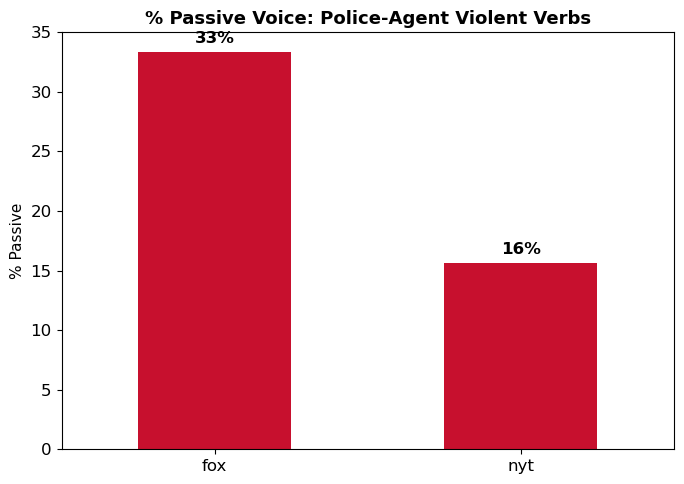

Panel 1 saved.


In [22]:
fig1, ax1 = plt.subplots(figsize=(7, 5))

police_agent = df[df["agent_category"] == "police"]
voice_pct = (
    police_agent.groupby(["outlet", "voice"]).size()
    .groupby(level=0).apply(lambda x: 100 * x / x.sum())
    .unstack(fill_value=0)
)
voice_pct.index = voice_pct.index.get_level_values(0)

voice_pct[["passive"]].plot(
    kind="bar", ax=ax1, rot=0,
    color= ["#C7102E", "#1F4E79"]
)
ax1.set_title("% Passive Voice: Police-Agent Violent Verbs", fontweight="bold")
ax1.set_ylabel("% Passive")
ax1.set_xlabel("")
if ax1.get_legend(): ax1.get_legend().remove()
for i, v in enumerate(voice_pct["passive"]):
    ax1.text(i, v + 0.8, f"{v:.0f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Panel 2: Hedging rate

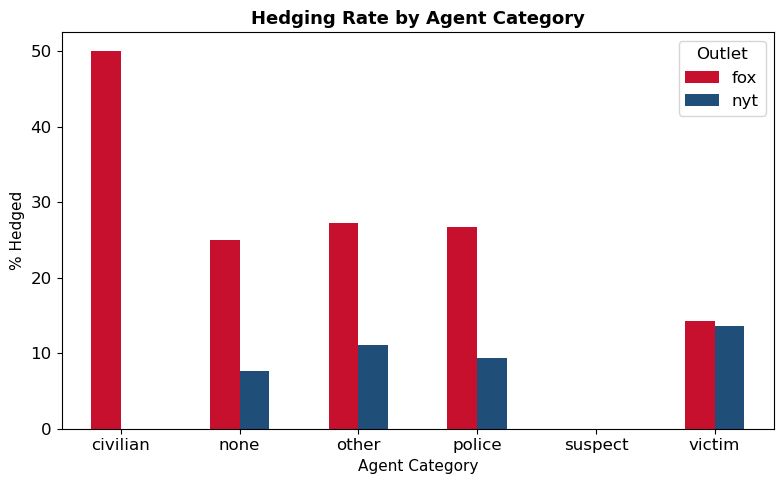

Panel 2 saved.


In [15]:
fig2, ax2 = plt.subplots(figsize=(8, 5))

hedge_pct = (
    df.groupby(["outlet", "agent_category"])["hedged"]
    .mean() * 100
).unstack(fill_value=0)

hedge_pct.T.plot(
    kind="bar", ax=ax2, rot=0,
    color=[OUTLET_COLORS.get(o, "gray") for o in hedge_pct.index]
)
ax2.set_title("Hedging Rate by Agent Category", fontweight="bold")
ax2.set_ylabel("% Hedged")
ax2.set_xlabel("Agent Category")
ax2.legend(title="Outlet")

plt.tight_layout()
plt.show()

### Panel 3: Agency attribution

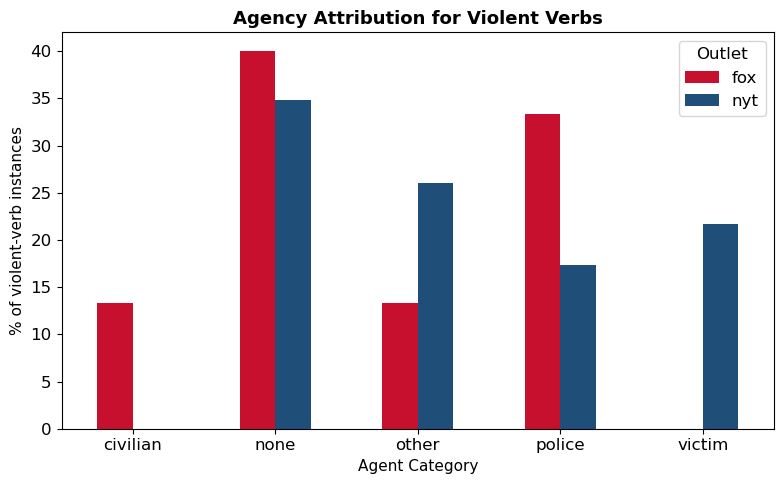

Panel 3 saved.


In [16]:
fig3, ax3 = plt.subplots(figsize=(8, 5))

v_df = df[df["verb_lemma"].isin(violent_set)]
agent_pct = (
    v_df.groupby(["outlet", "agent_category"]).size()
    .groupby(level=0).apply(lambda x: 100 * x / x.sum())
    .unstack(fill_value=0)
)
agent_pct.index = agent_pct.index.get_level_values(0)

agent_pct.T.plot(
    kind="bar", ax=ax3, rot=0,
    color=[OUTLET_COLORS.get(o, "gray") for o in agent_pct.index]
)
ax3.set_title("Agency Attribution for Violent Verbs", fontweight="bold")
ax3.set_ylabel("% of violent-verb instances")
ax3.set_xlabel("Agent Category")
ax3.legend(title="Outlet")

plt.tight_layout()
plt.show()

### Panel 4: Verb frequency

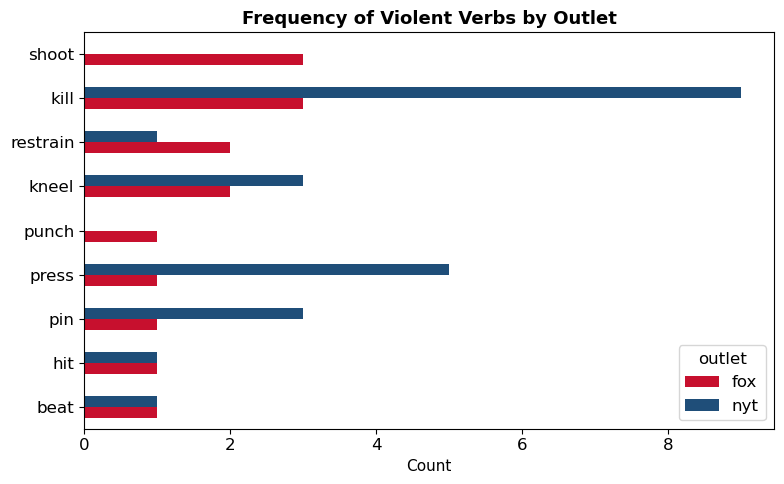

Panel 4 saved.


In [17]:
fig4, ax4 = plt.subplots(figsize=(8, 5))

top = (
    df[df["verb_lemma"].isin(violent_set)]
    .groupby(["outlet", "verb_lemma"]).size()
    .reset_index(name="count")
)
top_pivot = (
    top.pivot(index="verb_lemma", columns="outlet", values="count")
    .fillna(0)
)
top_pivot.columns = top_pivot.columns.get_level_values(0)
top_pivot = top_pivot.sort_values(top_pivot.columns[0])

top_pivot.plot(
    kind="barh", ax=ax4,
    color=[OUTLET_COLORS.get(o, "gray") for o in top_pivot.columns]
)
ax4.set_title("Frequency of Violent Verbs by Outlet", fontweight="bold")
ax4.set_xlabel("Count")
ax4.set_ylabel("")

plt.tight_layout()
plt.show()

---
## 13. Key Findings Summary

A final summary cell that prints the headline numbers for the report and poster.

In [18]:
print("=" * 55)
print("KEY FINDINGS")
print("=" * 55)

print("\n1. PASSIVE VOICE (police-agent violent clauses)")
print(voice_pct[["passive"]].round(1).to_string())

print("\n2. HEDGING RATE by agent category")
print(hedge_pct.round(1).to_string())

print("\n3. AGENCY ATTRIBUTION (violent verbs)")
print(agent_pct.round(1).to_string())

print("\n4. EUPHEMISM TOTALS by outlet")
if not euph_df.empty:
    print(euph_df.groupby(["outlet", "type"])["count"].sum().unstack(fill_value=0))

print(f"\n5. CHI-SQUARE TEST (agent category x outlet)")
print(f"   chi^2={chi2:.2f}, dof={dof}, p={pval:.4f}")
print(f"   {'Significant' if pval < 0.05 else 'Not significant'} at p < 0.05")
print("=" * 55)

KEY FINDINGS

1. PASSIVE VOICE (police-agent violent clauses)
voice   passive
outlet         
fox        33.3
nyt        15.6

2. HEDGING RATE by agent category
agent_category  civilian  none  other  police  suspect  victim
outlet                                                        
fox                 50.0  25.0   27.3    26.7      0.0    14.3
nyt                  0.0   7.7   11.1     9.4      0.0    13.6

3. AGENCY ATTRIBUTION (violent verbs)
agent_category  civilian  none  other  police  victim
outlet                                               
fox                 13.3  40.0   13.3    33.3     0.0
nyt                  0.0  34.8   26.1    17.4    21.7

4. EUPHEMISM TOTALS by outlet
type    direct  euphemism
outlet                   
fox          2          0
nyt          2         14

5. CHI-SQUARE TEST (agent category x outlet)
   chi^2=8.07, dof=4, p=0.0890
   Not significant at p < 0.05
